# Decision boundaries
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/src/data/am_pm.csv')
display(df)

,date,pm,am,target,predict
0,2020-04-17,2,21,working_day,weekend
1,2020-04-18,68,1,weekend,working_day
2,2020-04-19,15,18,weekend,working_day
3,2020-04-20,23,2,working_day,working_day
4,2020-04-21,25,0,working_day,working_day
5,2020-04-22,28,0,working_day,working_day
6,2020-04-23,33,10,working_day,working_day
7,2020-04-24,14,2,working_day,working_day
8,2020-04-25,74,30,weekend,working_day
9,2020-04-26,233,28,weekend,working_day


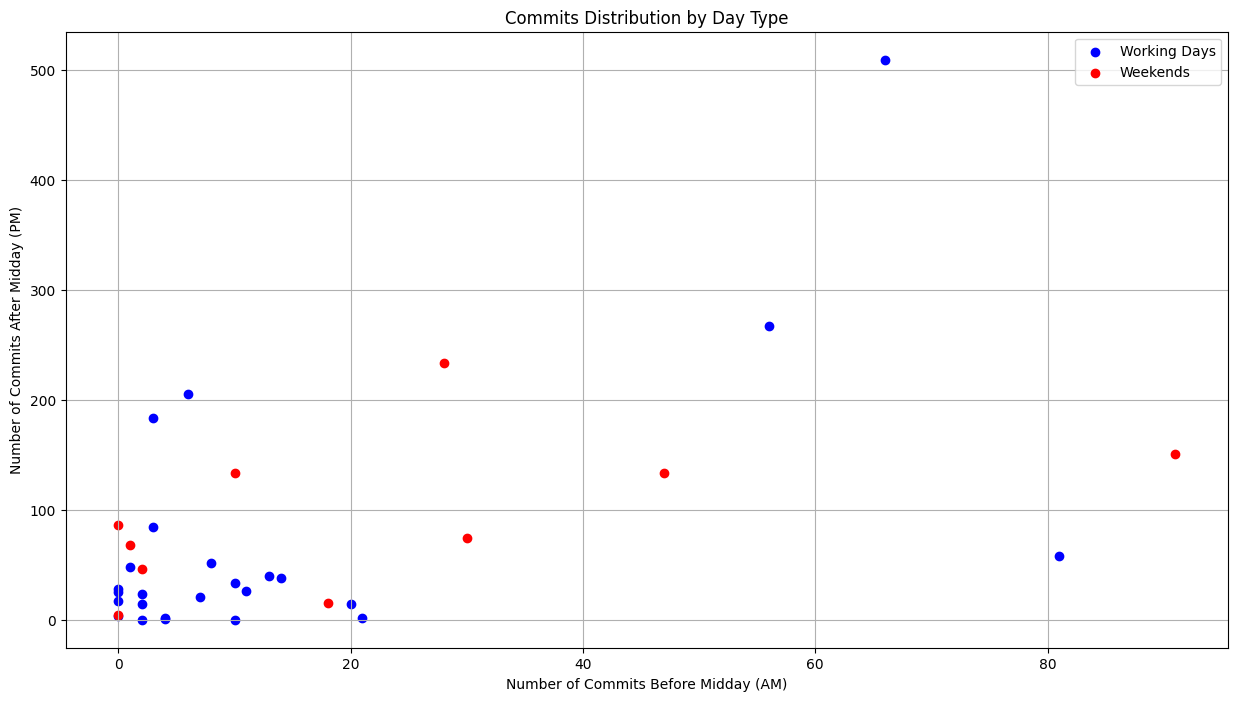

In [3]:
working_days = df[df['target'] == 'working_day']
weekends = df[df['target'] == 'weekend']

plt.figure(figsize=(15, 8))
plt.scatter(working_days['am'], working_days['pm'], color='blue', label='Working Days')
plt.scatter(weekends['am'], weekends['pm'], color='red', label='Weekends')

plt.xlabel('Number of Commits Before Midday (AM)')
plt.ylabel('Number of Commits After Midday (PM)')
plt.title('Commits Distribution by Day Type')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
x = df[['am', 'pm']]
y = (df['target'] == 'working_day').astype(int)
model = LogisticRegression(random_state=21, fit_intercept=False).fit(x, y)

/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


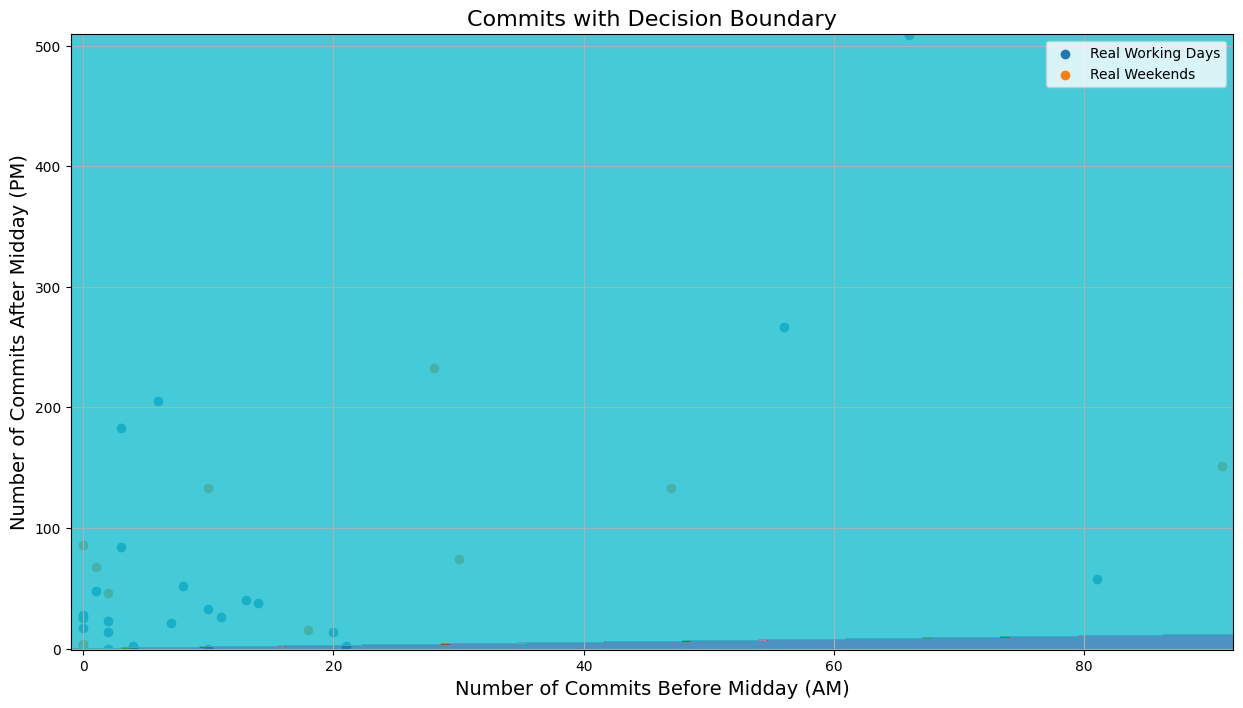

In [5]:
def plot_boundary(model, X, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    x_min, x_max = X['am'].min() - 1, X['am'].max() + 1
    y_min, y_max = X['pm'].min() - 1, X['pm'].max() + 1
    h = 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.8)
    return ax


plt.figure(figsize=(15, 8))
working_days = df[df['target'] == 'working_day']
weekends = df[df['target'] == 'weekend']
plt.scatter(working_days['am'], working_days['pm'], color='#1F77B4', label='Real Working Days')
plt.scatter(weekends['am'], weekends['pm'], color="#FF7F0E", label='Real Weekends')
current_ax = plt.gca()
plot_boundary(model, x, ax=current_ax)
plt.xlabel('Number of Commits Before Midday (AM)', fontsize=14)
plt.ylabel('Number of Commits After Midday (PM)', fontsize=14)
plt.title('Commits with Decision Boundary', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


/Users/cleganeb/Desktop/DSB10_Intro_to_ML.ID_1577653-1/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


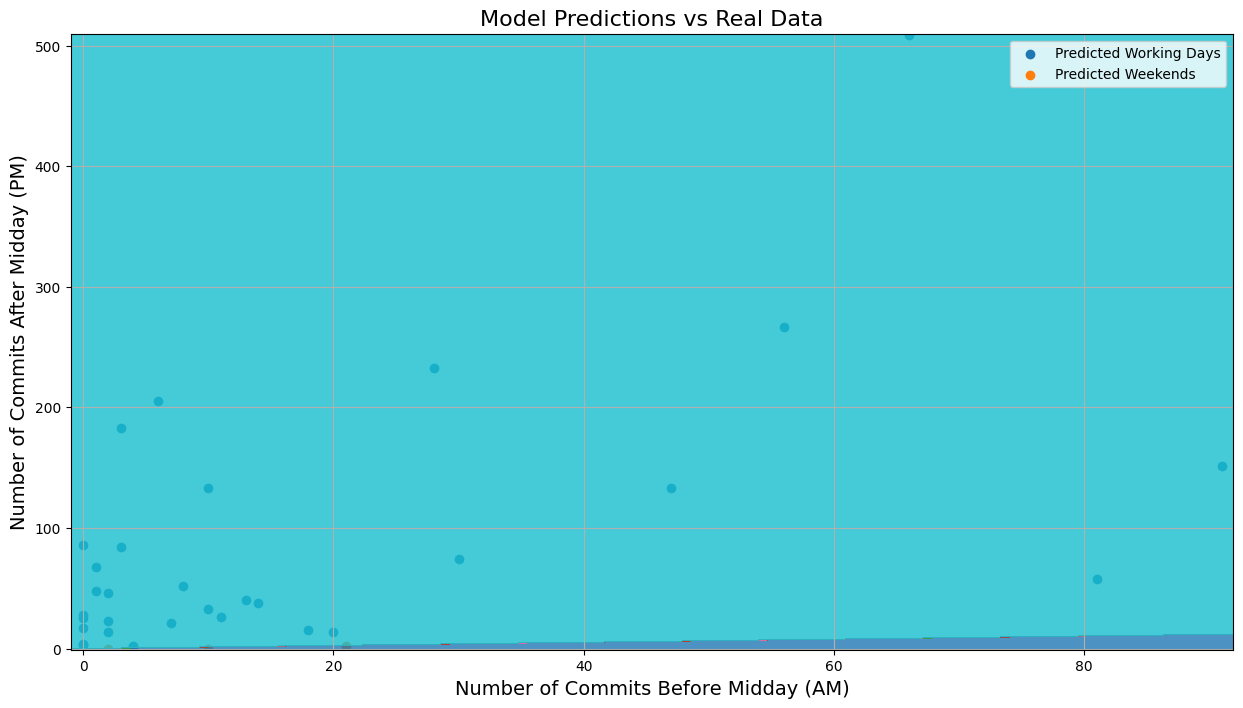

In [6]:
predicted_working_days = df[df['predict'] == 'working_day']
predicted_weekends = df[df['predict'] == 'weekend']
plt.figure(figsize=(15, 8))
plt.scatter(predicted_working_days['am'], predicted_working_days['pm'], color='#1F77B4', label='Predicted Working Days')
plt.scatter(predicted_weekends['am'], predicted_weekends['pm'], color="#FF7F0E", label='Predicted Weekends')
current_ax = plt.gca()
plot_boundary(model, x, ax=current_ax) 
plt.xlabel('Number of Commits Before Midday (AM)', fontsize=14)
plt.ylabel('Number of Commits After Midday (PM)', fontsize=14)
plt.title('Model Predictions vs Real Data', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [7]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model_scaled = LogisticRegression(random_state=21, fit_intercept=False, max_iter=1000).fit(x_scaled, y)

In [8]:
y_pred_scaled = model_scaled.predict(x_scaled)

accuracy_new = accuracy_score(y, y_pred_scaled)
print(f'Accuracy on scaled data: {accuracy_new:.4f}')

class_counts = Counter(y)
majority_class = class_counts.most_common()[0][0]
naive_accuracy = class_counts[majority_class] / len(y)
print(f"Accuracy of a simple classifier: {naive_accuracy:.4f}")
print("Is logistic regression better than naive?" , accuracy_new > naive_accuracy)

Accuracy on scaled data: 0.7429
Accuracy of a simple classifier: 0.7143
Is logistic regression better than naive? True


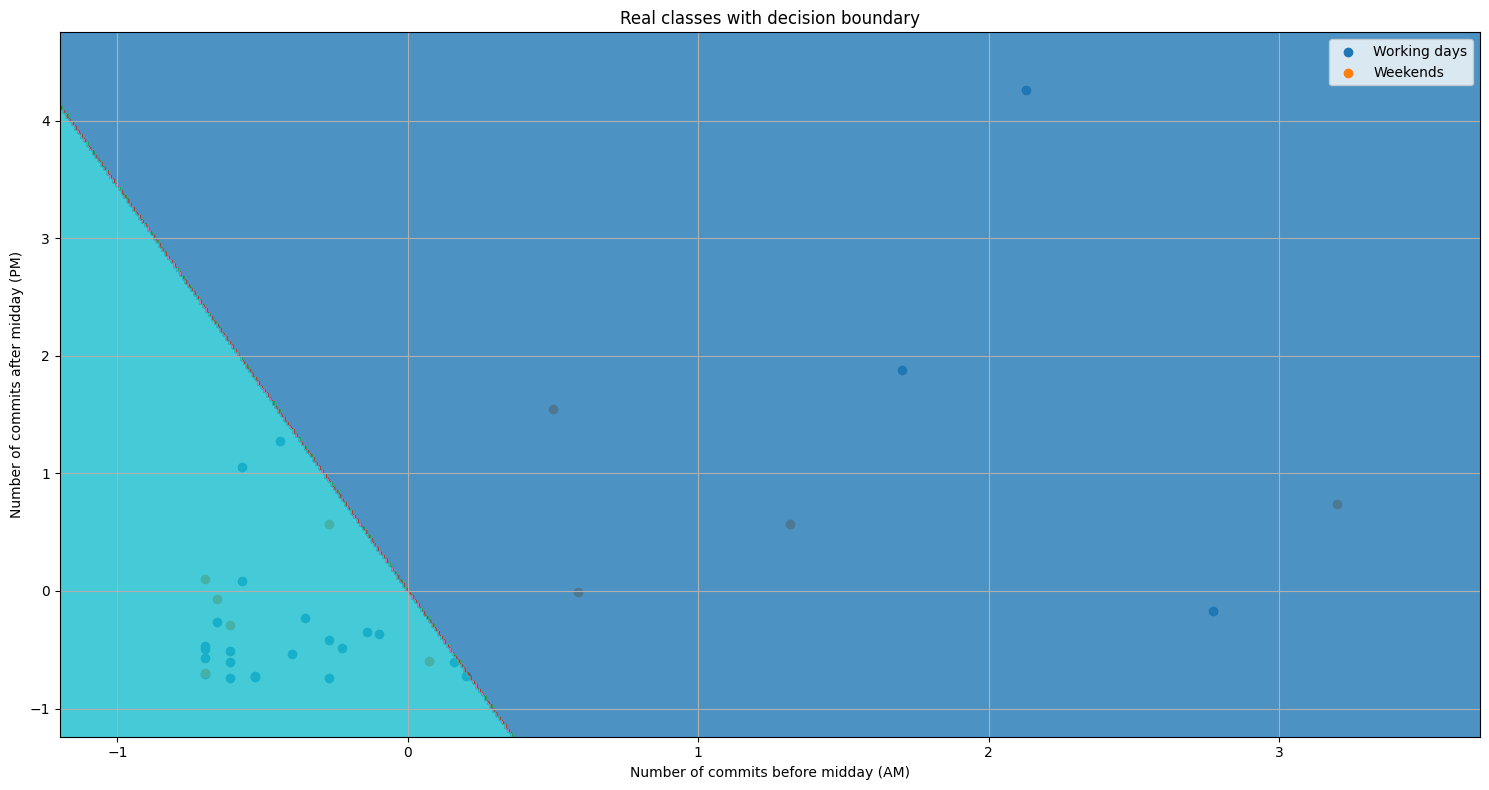

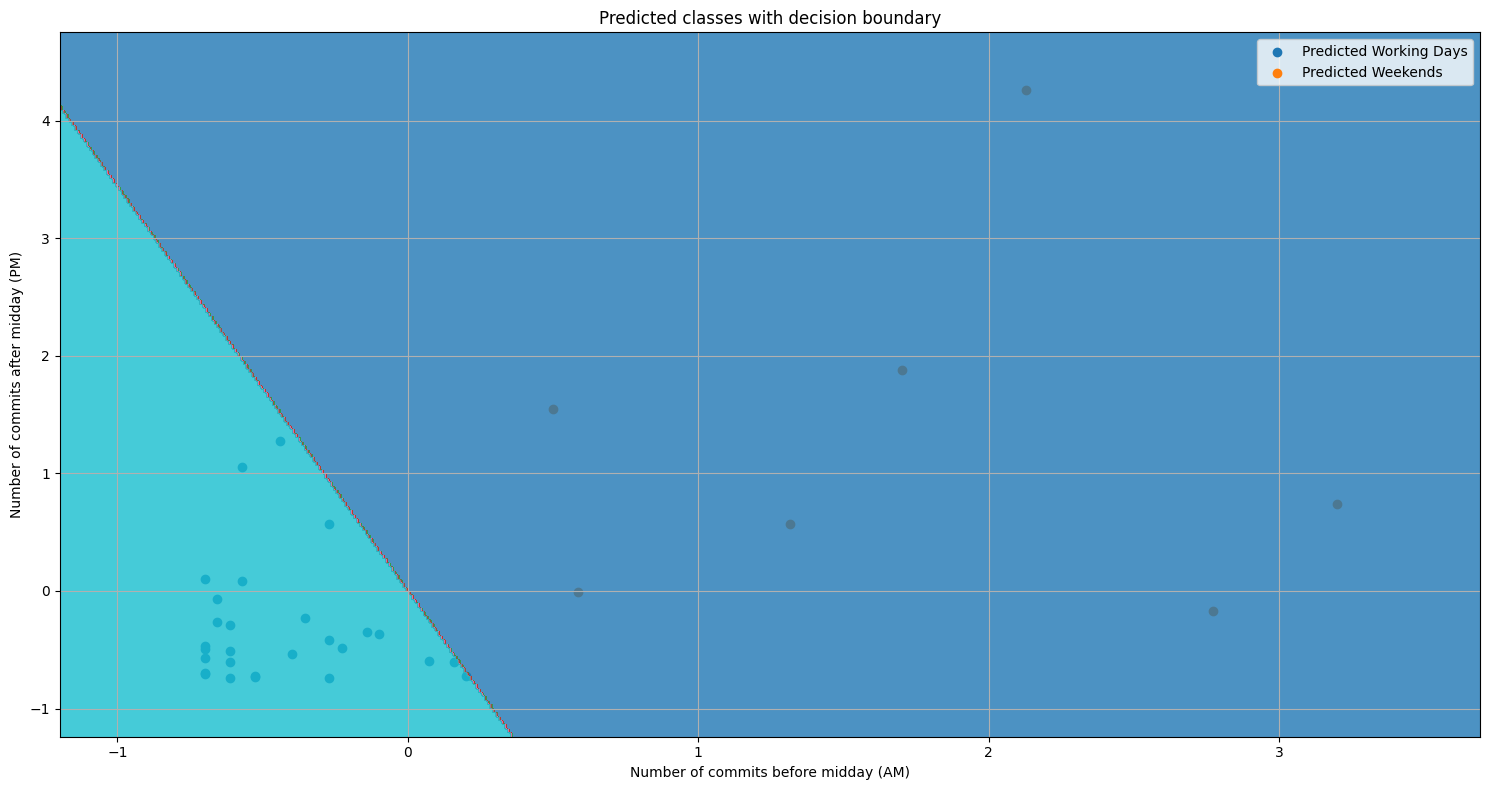

In [9]:
def plot_decision_boundary(model, X, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.8)

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x_scaled[(y == 1), 0], x_scaled[(y == 1), 1], color='#1F77B4', label='Working days')
ax.scatter(x_scaled[(y == 0), 0], x_scaled[(y == 0), 1], color="#FF7F0E", label='Weekends')
plot_decision_boundary(model_scaled, x_scaled, ax)
ax.set_xlabel('Number of commits before midday (AM)')
ax.set_ylabel('Number of commits after midday (PM)')
ax.set_title('Real classes with decision boundary')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x_scaled[(y_pred_scaled == 1), 0], x_scaled[(y_pred_scaled == 1), 1], color='#1F77B4', label='Predicted Working Days')
ax.scatter(x_scaled[(y_pred_scaled == 0), 0], x_scaled[(y_pred_scaled == 0), 1], color="#FF7F0E", label='Predicted Weekends')
plot_decision_boundary(model_scaled, x_scaled, ax)
ax.set_xlabel('Number of commits before midday (AM)')
ax.set_ylabel('Number of commits after midday (PM)')
ax.set_title('Predicted classes with decision boundary')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [10]:

svc_model = SVC(probability=True, random_state=21)
svc_model.fit(x_scaled, y)
y_pred = svc_model.predict(x_scaled)
accuracy = accuracy_score(y, y_pred)
print(f'SVС Accuracy: {accuracy:.4f}')

SVС Accuracy: 0.7429


In [11]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_scores = {}
best_kernels = []  
best_accuracy = 0

for kernel in kernels:
    svc_model = SVC(kernel=kernel, probability=True, random_state=21)
    svc_model.fit(x_scaled, y)
    y_pred = svc_model.predict(x_scaled)
    current_accuracy = accuracy_score(y, y_pred)

    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_kernels = [kernel] 
    elif current_accuracy == best_accuracy:
        best_kernels.append(kernel)
    kernel_scores[kernel] = current_accuracy
    print(f"{kernel}: Accuracy={current_accuracy:.4f}")

if len(best_kernels) == 1:
    print(f"\nBest kernel: {best_kernels[0]}, Best accuracy: {best_accuracy:.4f}")
else:
    print(f"\nMultiple best kernels found ({len(best_kernels)}): {best_kernels}, All have accuracy: {best_accuracy:.4f}")

linear: Accuracy=0.7143
poly: Accuracy=0.7429
rbf: Accuracy=0.7429
sigmoid: Accuracy=0.6857

Multiple best kernels found (2): ['poly', 'rbf'], All have accuracy: 0.7429


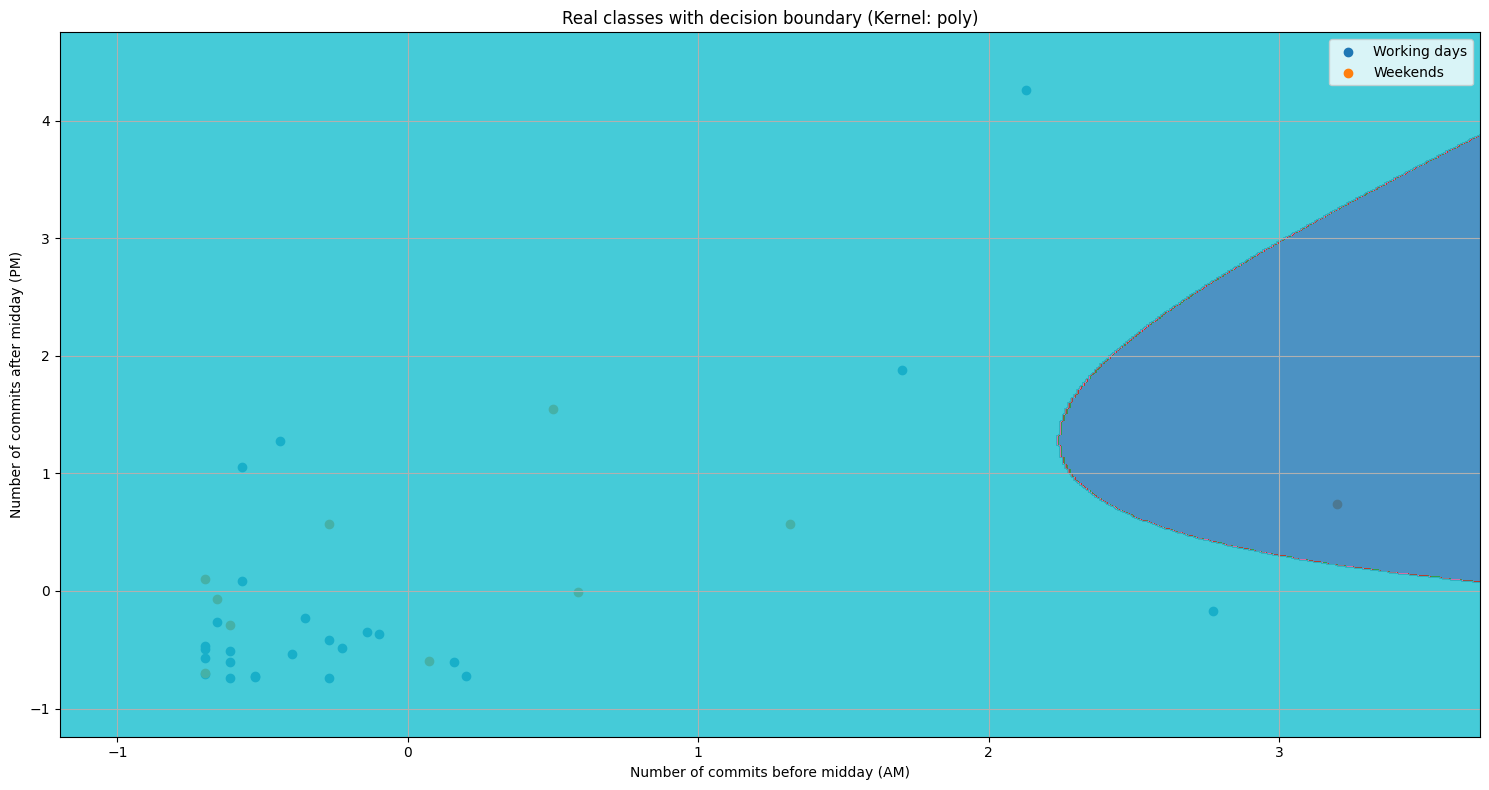

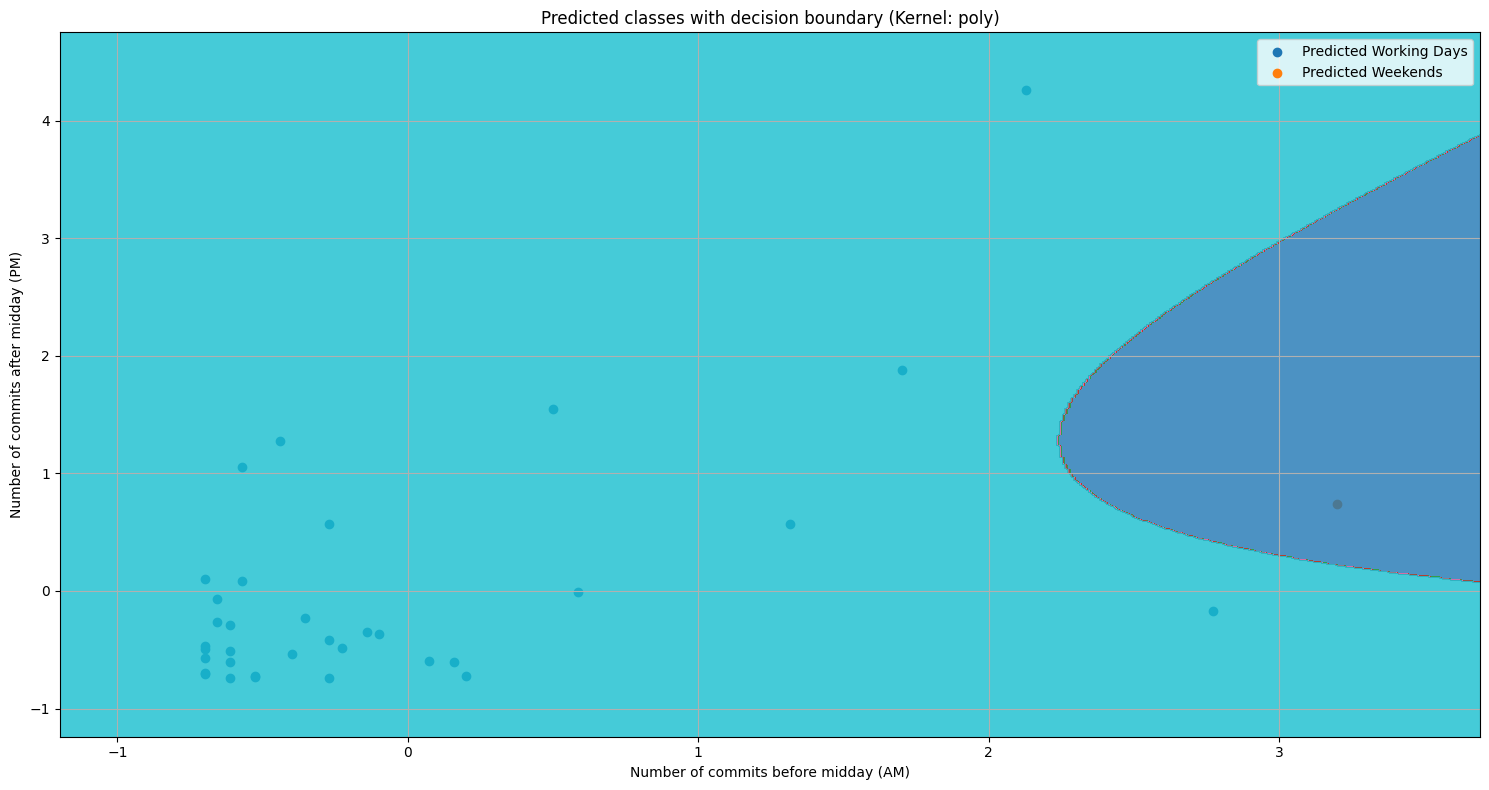

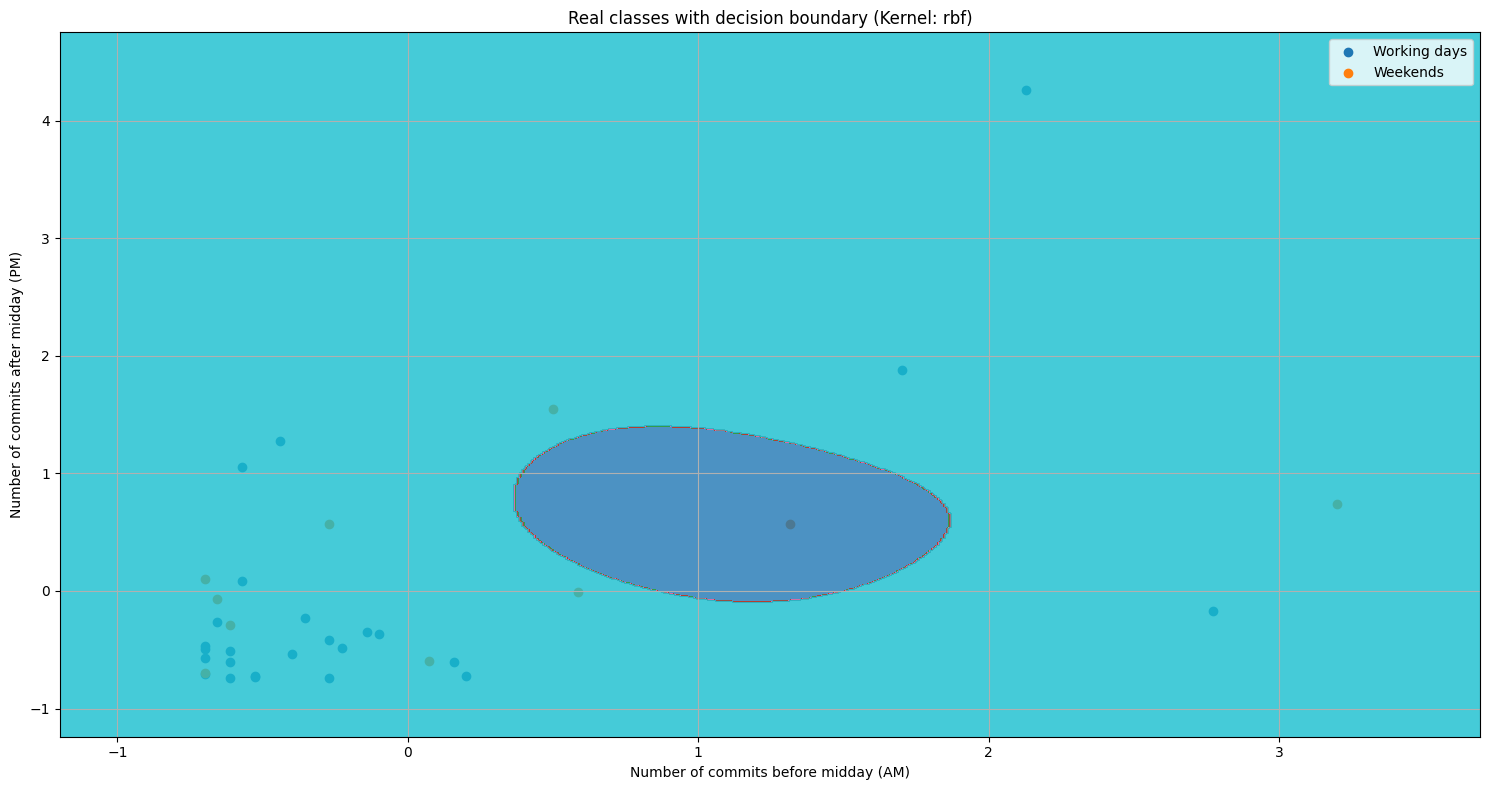

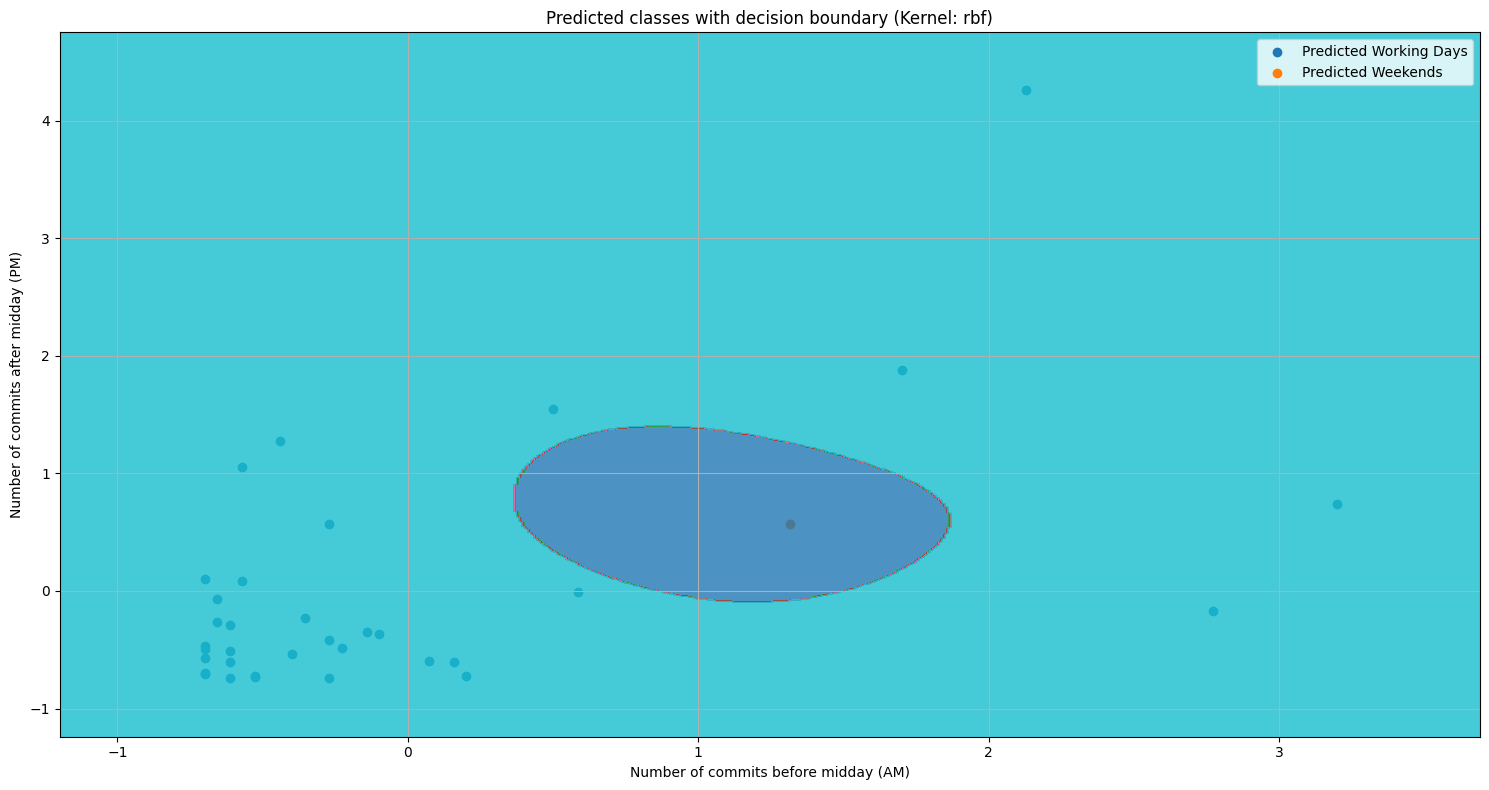

In [12]:


for kernel in best_kernels:
    svc_model = SVC(kernel=kernel, probability=True, random_state=21)
    svc_model.fit(x_scaled, y)
    y_pred = svc_model.predict(x_scaled)

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.scatter(x_scaled[(y == 1), 0], x_scaled[(y == 1), 1], color='#1F77B4', label='Working days')
    ax.scatter(x_scaled[(y == 0), 0], x_scaled[(y == 0), 1], color="#FF7F0E", label='Weekends')
    plot_decision_boundary(svc_model, x_scaled, ax)
    ax.set_xlabel('Number of commits before midday (AM)')
    ax.set_ylabel('Number of commits after midday (PM)')
    ax.set_title(f'Real classes with decision boundary (Kernel: {kernel})')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.scatter(x_scaled[(y_pred == 1), 0], x_scaled[(y_pred == 1), 1], color='#1F77B4', label='Predicted Working Days')
    ax.scatter(x_scaled[(y_pred == 0), 0], x_scaled[(y_pred == 0), 1], color="#FF7F0E", label='Predicted Weekends')
    plot_decision_boundary(svc_model, x_scaled, ax)
    ax.set_xlabel('Number of commits before midday (AM)')
    ax.set_ylabel('Number of commits after midday (PM)')
    ax.set_title(f'Predicted classes with decision boundary (Kernel: {kernel})')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [13]:
dtc_1 = DecisionTreeClassifier(max_depth=4, random_state=42)
dtc_1.fit(x_scaled, y)
y_pred = dtc_1.predict(x_scaled)
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy: {accuracy:.4f}')

depth_scores = {}
for d in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=d, random_state=42)
    dtc.fit(x_scaled, y)
    depth_scores[d] = accuracy_score(y, dtc.predict(x_scaled))

display(depth_scores)

Accuracy: 0.9429


{1: 0.7714285714285715,
 2: 0.8571428571428571,
 3: 0.8857142857142857,
 4: 0.9428571428571428,
 5: 0.9714285714285714,
 6: 1.0,
 7: 1.0,
 8: 1.0,
 9: 1.0,
 10: 1.0}

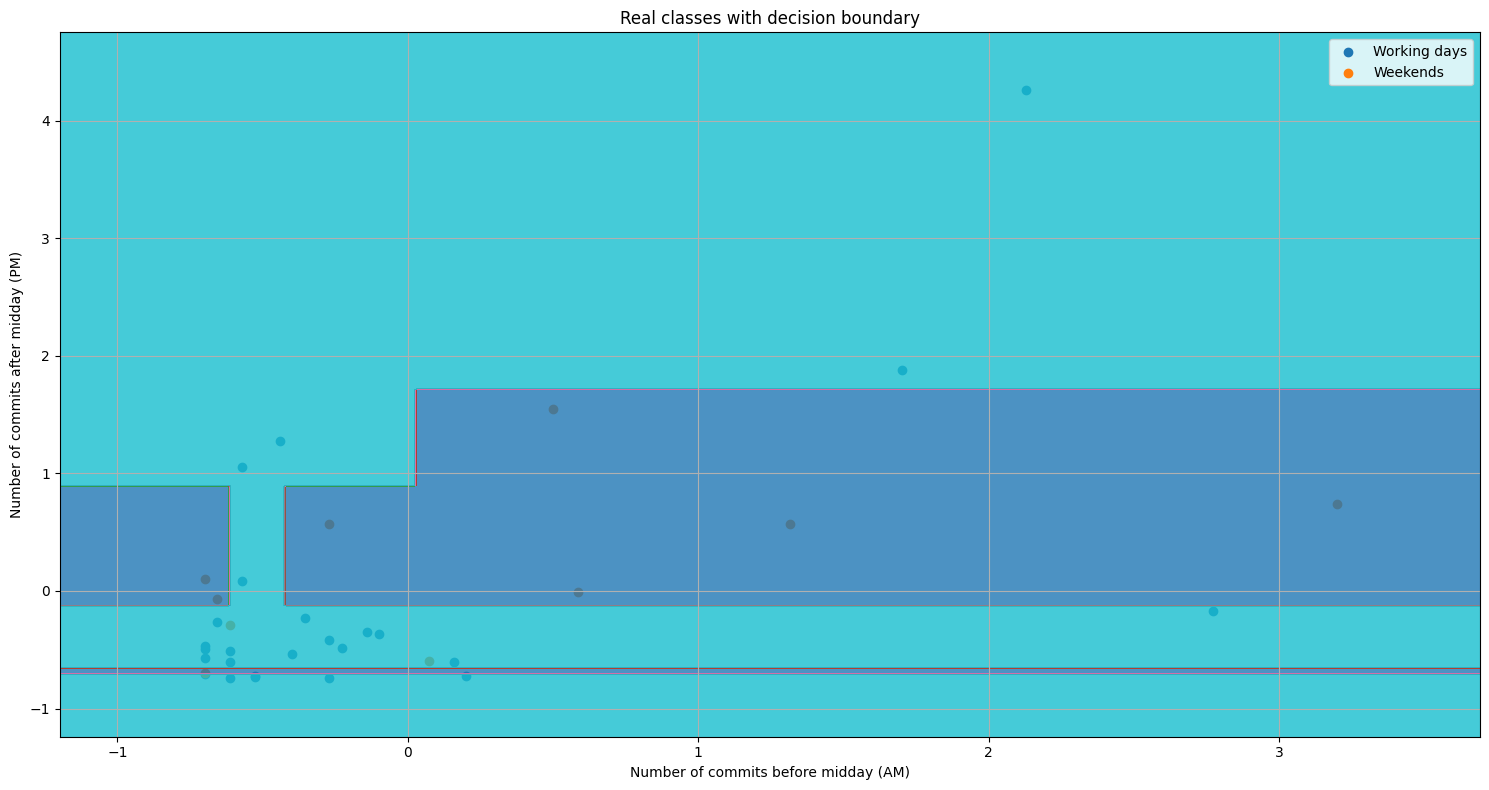

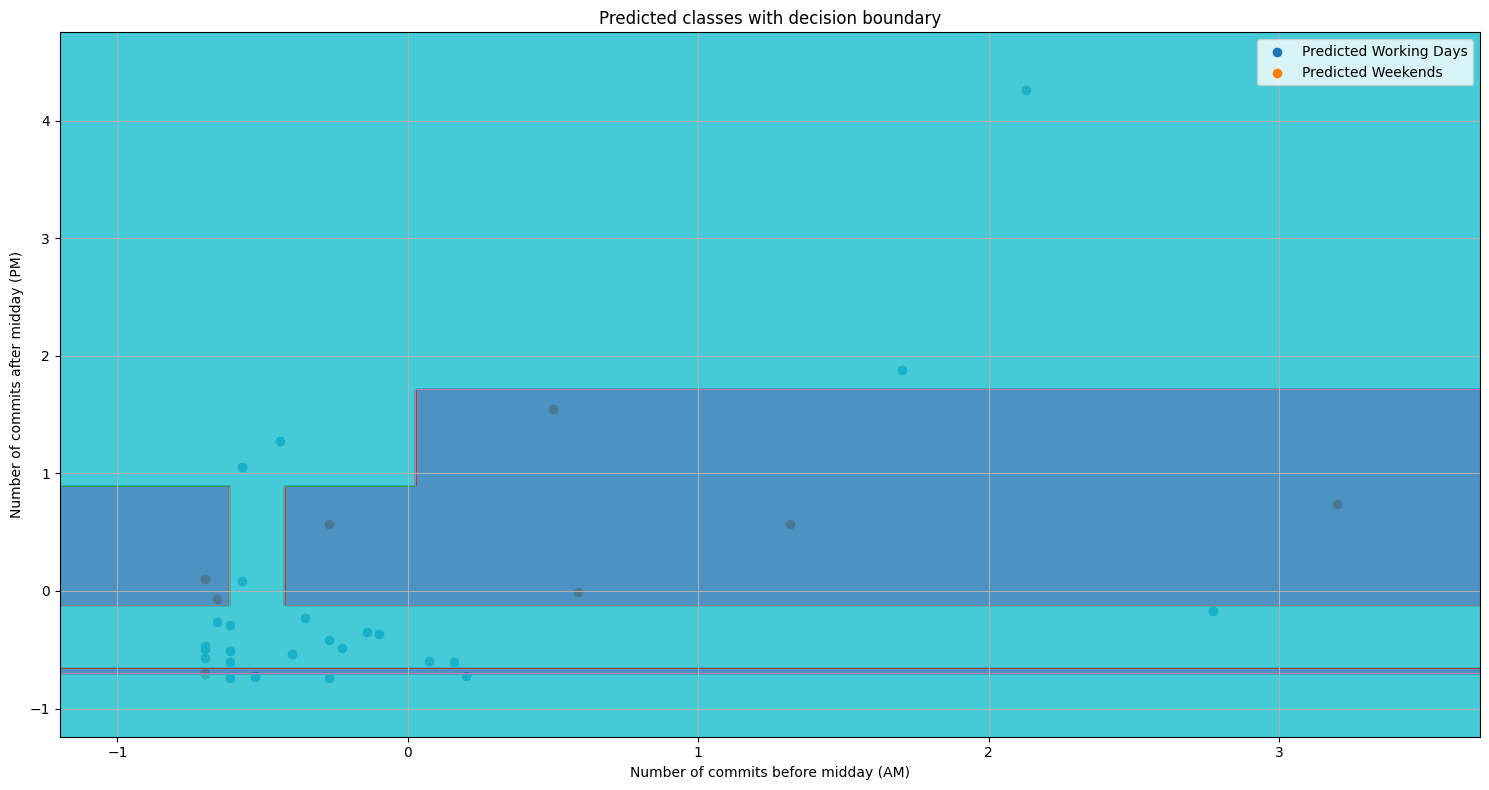

In [14]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x_scaled[(y == 1), 0], x_scaled[(y == 1), 1], color='#1F77B4', label='Working days')
ax.scatter(x_scaled[(y == 0), 0], x_scaled[(y == 0), 1], color="#FF7F0E", label='Weekends')
plot_decision_boundary(dtc_1, x_scaled, ax)  # Убедитесь, что эта функция определена
ax.set_xlabel('Number of commits before midday (AM)')
ax.set_ylabel('Number of commits after midday (PM)')
ax.set_title('Real classes with decision boundary')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x_scaled[(y_pred == 1), 0], x_scaled[(y_pred == 1), 1], color='#1F77B4', label='Predicted Working Days')
ax.scatter(x_scaled[(y_pred == 0), 0], x_scaled[(y_pred == 0), 1], color="#FF7F0E", label='Predicted Weekends')
plot_decision_boundary(dtc_1, x_scaled, ax)  # Убедитесь, что эта функция определена
ax.set_xlabel('Number of commits before midday (AM)')
ax.set_ylabel('Number of commits after midday (PM)')
ax.set_title('Predicted classes with decision boundary')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

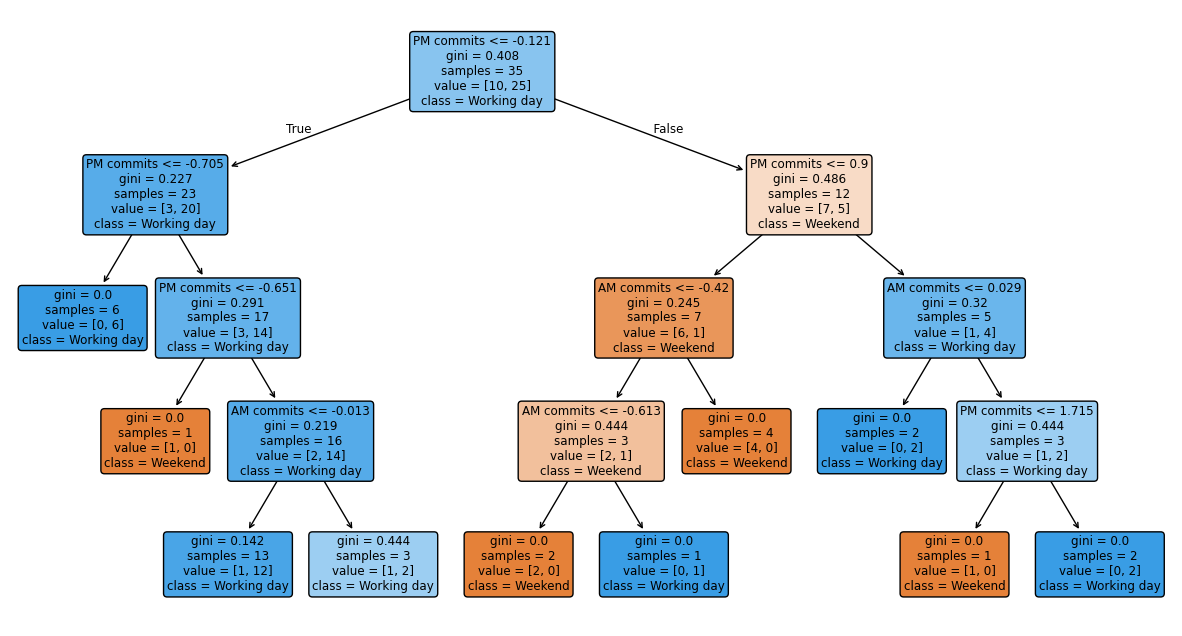

In [15]:
plt.figure(figsize=(15, 8))
plot_tree(dtc_1, filled=True, rounded=True, feature_names=['AM commits', 'PM commits'], class_names=['Weekend', 'Working day'])
plt.show()

In [16]:
leaves = dtc_1.apply(x_scaled)
unique_leaves, counts = np.unique(leaves, return_counts=True)

leaf_labels = []
for leaf_id in unique_leaves:
    idxs = np.where(leaves == leaf_id)[0]
    if len(idxs) > 0 and y[idxs].mean() >= 0.5: 
        leaf_labels.append((leaf_id, "working day"))
    else:
        leaf_labels.append((leaf_id, "weekend"))
        
num_working_day_leaves = sum([1 for _, label in leaf_labels if label == "working day"])

print(f"The number of leaves representing the working days: {num_working_day_leaves}")

The number of leaves representing the working days: 6
